# EOSC442 project

In [48]:
pip install seaborn statsmodels

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Raw Plot for showing general trend

In [49]:
o3 = pd.read_csv('Continuous_O3_105001_2023.csv')

In [50]:
# Convert datetime column
o3["Date_GMT"] = pd.to_datetime(o3["Date_GMT"])

# Extract date only (remove hour component)
o3["Date"] = o3["Date_GMT"].dt.date

# Calculate daily mean PM2.5
o3_daily_mean = (
    o3.groupby("Date")["Value"]
    .mean()
    .reset_index()
    .rename(columns={"Value": "Daily Mean O3"})
)

# Convert Date back to datetime (optional but recommended)
o3_daily_mean["Date"] = pd.to_datetime(o3_daily_mean["Date"])

# Create full 2023 date range
full_dates = pd.date_range(start="2023-01-01", end="2023-12-31")

# Set Date as index
o3_daily_mean = o3_daily_mean.set_index("Date")

# Reindex to full year
o3_daily_mean = o3_daily_mean.reindex(full_dates)

# Rename index back to column
o3_daily_mean = o3_daily_mean.rename_axis("Date").reset_index()

In [51]:
df = pd.merge(
    pm25_daily_mean,
    climate_new,
    left_on="Date",
    right_on="Date/Time",
    how="inner"
)
df= pd.merge(
    df,
    o3_daily_mean,
    left_on="Date",
    right_on="Date",
    how="inner"
)


X = df[["Date", "Mean Temp (°C)", "Temp Range (°C)", "Total Precip (mm)", "Daily Mean PM2.5", "Daily Mean O3"]]
X = X.set_index('Date')
X

,Mean Temp (°C),Temp Range (°C),Total Precip (mm),Daily Mean PM2.5,Daily Mean O3
Date,,,,,
2023-01-01,-0.5,4.2,0.0,7.500000,15.933333
2023-01-02,-2.7,4.5,0.0,2.800000,19.130435
2023-01-03,-2.8,4.7,0.2,1.454545,22.173913
2023-01-04,-3.2,4.8,0.0,4.454545,21.043478
2023-01-05,-0.6,2.3,5.6,0.782609,30.739130
...,...,...,...,...,...
2023-12-27,0.7,2.8,4.6,5.333333,15.173913
2023-12-28,3.4,4.3,8.3,9.458333,4.652174
2023-12-29,3.7,3.7,0.2,6.125000,8.739130


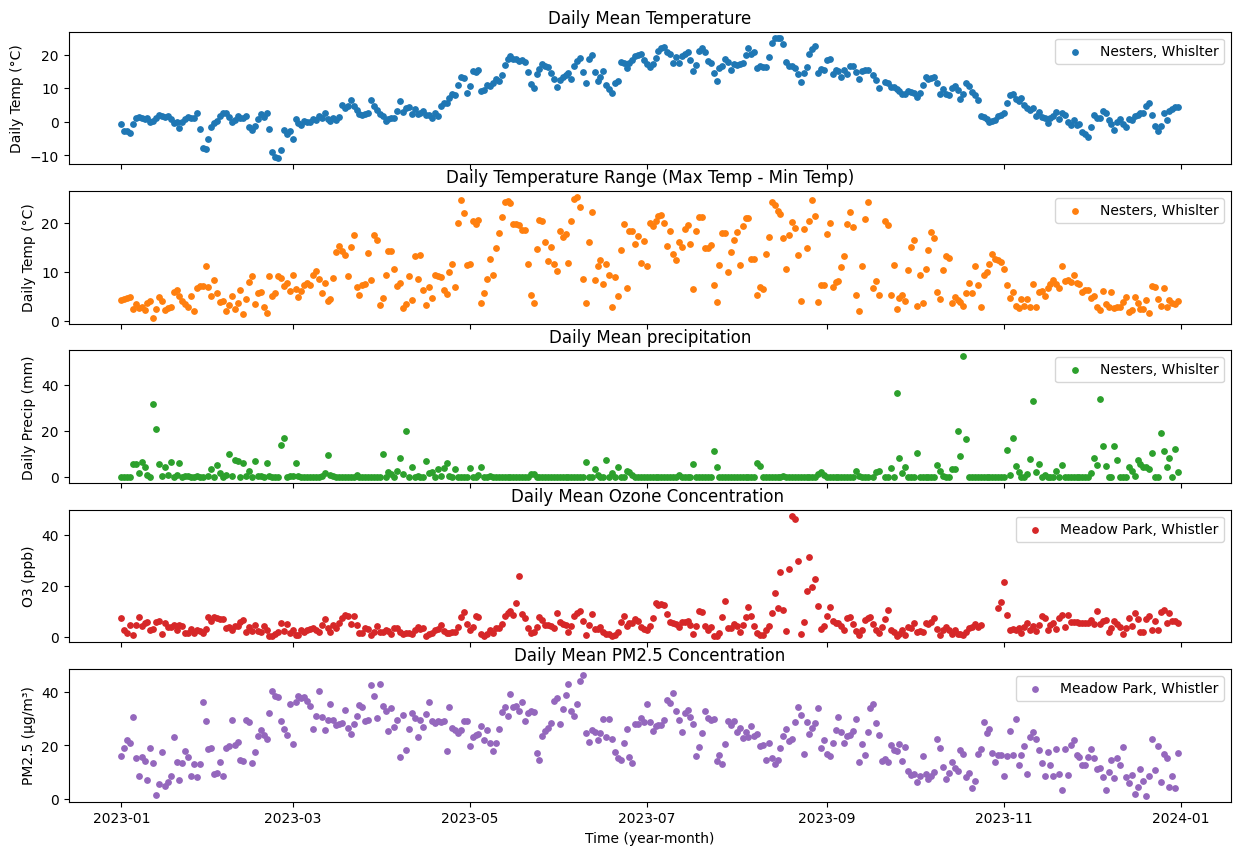

In [52]:
titles = ['Daily Mean Temperature','Daily Temperature Range (Max Temp - Min Temp)','Daily Mean precipitation','Daily Mean Ozone Concentration ','Daily Mean PM2.5 Concentration']
colors = sns.color_palette(None, len(X.columns))
col_keys = ["Mean Temp (°C)", "Temp Range (°C)", "Total Precip (mm)", "Daily Mean PM2.5", "Daily Mean O3"]
labels = ['Daily Temp (°C)', 'Daily Temp (°C)', 'Daily Precip (mm)','O3 (ppb)','PM2.5 (µg/m³)']
location = ['Nesters, Whislter', 'Nesters, Whislter', 'Nesters, Whislter', 'Meadow Park, Whistler', 'Meadow Park, Whistler']
# initialize your figure with a figure handle
fig1, ax = plt.subplots(5, figsize=[15,10], sharex = True)

# loop through each column of the dataframe
for ii in range(5):
    # activate the subplot
    # plot the time-series
    ax[ii].scatter(X.index, X[col_keys[ii]], color = colors[ii], label = location[ii], s=15)
    # add figure elements
    ax[ii].set_title(titles[ii])
    ax[ii].set_ylabel(labels[ii])
    ax[ii].legend()


ax[4].set_xlabel('Time (year-month)')
# get the axes for the subplots, we will use these later
axes = fig1.get_axes()

fig1.savefig("daily_time_series.png", dpi=300, bbox_inches="tight")


## Q3
### Is there a statistically significant negative linear Pearson correlation between total daily precipitation and daily mean PM2.5 concentration?

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
import numpy as np
import scipy.stats as stat
import statsmodels.api as sm

pm25 = pd.read_csv('Continuous_PM2.5_105001_2023.csv')
climate = pd.read_csv('en_climate_daily_BC_1100875_2023_P1D.csv')

In [54]:
# pm25 was recorded hourly and climate was recorded daily
# we want pm25 to be daily as well by calculating daily mean pm25

# Convert datetime column
pm25["Date_GMT"] = pd.to_datetime(pm25["Date_GMT"])

# Extract date only (remove hour component)
pm25["Date"] = pm25["Date_GMT"].dt.date

# Calculate daily mean PM2.5
pm25_daily_mean = (
    pm25.groupby("Date")["Value"]
    .mean()
    .reset_index()
    .rename(columns={"Value": "Daily Mean PM2.5"})
)

# Convert Date back to datetime (optional but recommended)
pm25_daily_mean["Date"] = pd.to_datetime(pm25_daily_mean["Date"])

# Create full 2023 date range
full_dates = pd.date_range(start="2023-01-01", end="2023-12-31")

# Set Date as index
pm25_daily_mean = pm25_daily_mean.set_index("Date")

# Reindex to full year
pm25_daily_mean = pm25_daily_mean.reindex(full_dates)

# Rename index back to column
pm25_daily_mean = pm25_daily_mean.rename_axis("Date").reset_index()

In [55]:
# for Q3, we only need pm25, total precipitation, and date
climate_preci = climate[['Date/Time', 'Total Precip (mm)']]
climate_date_preci = climate_preci.set_index('Date/Time')

pm25_value = pm25_daily_mean[['Date', 'Daily Mean PM2.5']]
pm25_date_value = pm25_value.set_index('Date')

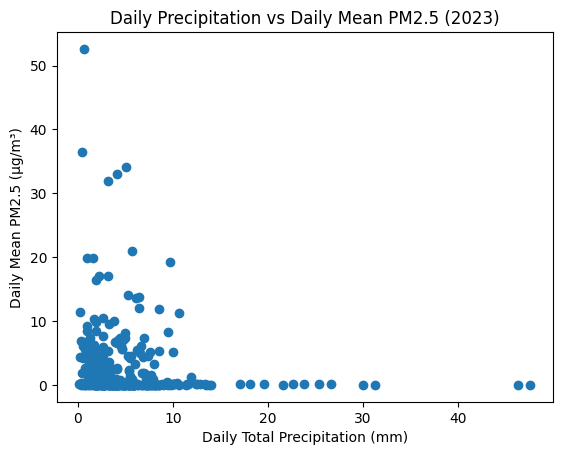

In [56]:
plt.scatter(pm25_date_value,climate_date_preci)
plt.xlabel("Daily Total Precipitation (mm)")
plt.ylabel("Daily Mean PM2.5 (µg/m³)")
plt.title("Daily Precipitation vs Daily Mean PM2.5 (2023)")
plt.show()

In [57]:
climate_date_preci.index = pd.to_datetime(climate_date_preci.index)
pm25_date_value.index = pd.to_datetime(pm25_date_value.index)

new_df = pm25_date_value.join(climate_date_preci, how='inner').dropna()


X = new_df['Total Precip (mm)'].values.reshape(-1,1)
y = new_df['Daily Mean PM2.5']

print(X.shape, y.shape)
# linear regression
reg = LinearRegression()
reg.fit(X, y)
predict = reg.predict(X)

trend = np.array2string(np.around(reg.coef_[0], decimals=4))
intercept = np.array2string(np.around(reg.intercept_, decimals=4))
r2 = np.array2string(np.around(reg.score(X, y), decimals=4))


(357, 1) (357,)


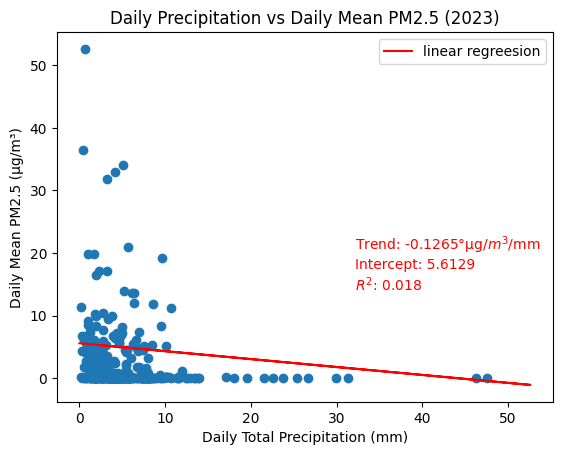

In [58]:
plt.scatter(new_df['Daily Mean PM2.5'], new_df['Total Precip (mm)'])
plt.plot(X, predict, label ='linear regreesion', color = 'r')
plt.xlabel("Daily Total Precipitation (mm)")
plt.ylabel("Daily Mean PM2.5 (µg/m³)")
plt.title("Daily Precipitation vs Daily Mean PM2.5 (2023)")
plt.annotate('Trend: ' + trend +'\u00b0μg/$m^3$/mm' + '\nIntercept: ' + intercept + '\n$R^2$: ' + r2, xy=(0.6, 0.3), xycoords='axes fraction', color='r')
plt.legend()
plt.show()

PearsonRResult(statistic=np.float64(-0.13415623999266105), pvalue=np.float64(0.011167991672236277))
(357,)


Text(0, 0.5, 'Daily Mean PM2.5 (µg/m³)')

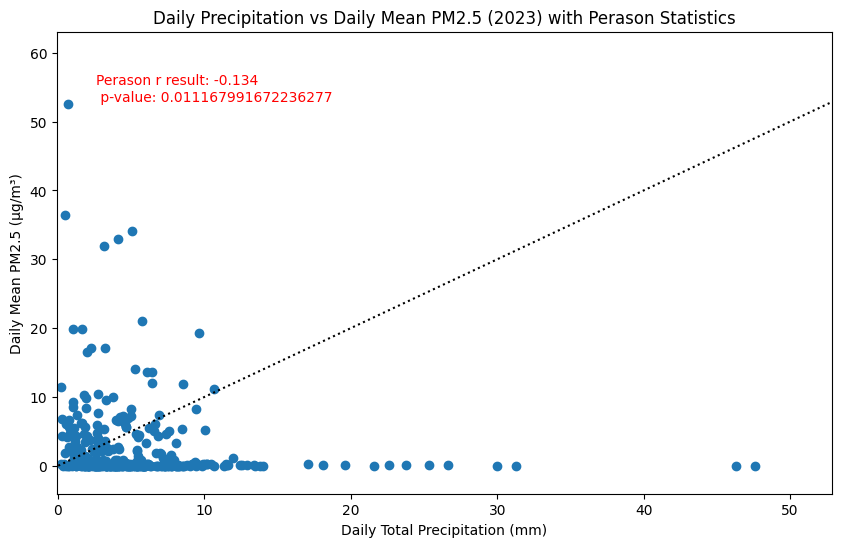

In [59]:
# Pearson correlation
a = stat.pearsonr(new_df['Daily Mean PM2.5'], new_df['Total Precip (mm)'])
print(a)
print(new_df['Daily Mean PM2.5'].shape)

fig2 = plt.figure(figsize = [10,6])

plt.scatter(new_df['Daily Mean PM2.5'], new_df['Total Precip (mm)'], marker = 'o')
plt.plot(np.linspace(-1,60,10), np.linspace(-1,60,10), linestyle =':', color = 'k')
plt.xlim(min(new_df['Daily Mean PM2.5'])-0.25, max(new_df['Total Precip (mm)'])+0.25)
plt.ylim()

plt.annotate('Perason r result: ' + str(np.round(a[0], 3)) + '\n p-value: ' + str(np.round(a[1],26)), xy =(0.05,0.85), xycoords = 'axes fraction', color = 'r')

plt.title('Daily Precipitation vs Daily Mean PM2.5 (2023) with Perason Statistics')
plt.xlabel("Daily Total Precipitation (mm)")
plt.ylabel("Daily Mean PM2.5 (µg/m³)")

## Q4
### Do daily mean temperature, daily temperature range, and total precipitation significantly predict daily mean PM2.5 concentrations using multiple linear regression?

In [60]:
climate = pd.read_csv('en_climate_daily_BC_1100875_2023_P1D.csv')

In [61]:
# we want temp range , mean temp, total precipitation
climate["Temp Range (°C)"] = climate["Max Temp (°C)"] - climate["Min Temp (°C)"]

climate_new = climate_vars = climate[[
    "Date/Time",
    "Mean Temp (°C)",
    "Temp Range (°C)",
    "Total Precip (mm)"
]]

climate_new["Date/Time"] = pd.to_datetime(climate_new["Date/Time"])
pm25_new = pm25_daily_mean

C:\Users\Jinseok Bae\AppData\Local\Temp\ipykernel_19196\1536833992.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  climate_new["Date/Time"] = pd.to_datetime(climate_new["Date/Time"])


In [62]:
# MLR
X = climate_new.iloc[:,1:4]
X = sm.add_constant(X)
y = pm25_new['Daily Mean PM2.5']

mlr = sm.OLS(y, X, missing = 'drop').fit()
mlr.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:       Daily Mean PM2.5   R-squared:                       0.210
Model:                            OLS   Adj. R-squared:                  0.203
Method:                 Least Squares   F-statistic:                     31.20
Date:                Mon, 10 Aug 2026   Prob (F-statistic):           6.50e-18
Time:                        20:12:28   Log-Likelihood:                -1061.5
No. Observations:                 357   AIC:                             2131.
Df Residuals:                     353   BIC:                             2147.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 1.3126      0.542      2.420      0.016       0.246       2.379
Mean Temp (°C)        0.0046      0.046      0.101      0.920      -0.085       0.094
Temp Range (°C)       0.3866      0.059      6.543      0.000       0.270       0.503
Total Precip (mm)     0.0312      0.048      0.651      0.516      -0.063       0.126
==============================================================================
Omnibus:                      344.473   Durbin-Watson:                   0.654
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            10582.472
Skew:                           4.097   Prob(JB):                         0.00
Kurtosis:                      28.383   Cond. No.                         34.5
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [63]:
# droping na before calculating errors 
## for fitting due to missing = 'drop', it do the job for us 
## but for calculating errors, we need to drop na manually

df = pd.merge(
    pm25_daily_mean,
    climate_new,
    left_on="Date",
    right_on="Date/Time",
    how="inner"
)
df = df.dropna()
y = df["Daily Mean PM2.5"]
X = df[["Mean Temp (°C)", "Temp Range (°C)", "Total Precip (mm)"]]
X = sm.add_constant(X)

# calculating MAE MSE RMSE
predict_pm25 = mlr.predict(X)

MAE = sm.tools.eval_measures.meanabs(y, predict_pm25)
MSE = sm.tools.eval_measures.mse(y, predict_pm25)
RMSE = sm.tools.eval_measures.rmse(y, predict_pm25)
print(MAE, MSE, RMSE)

2.8726536271114806 22.400701013845403 4.732937884004543


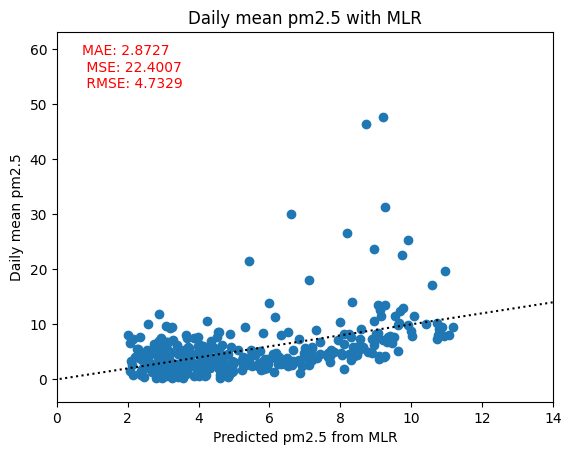

In [64]:
plt.scatter(predict_pm25, y)
plt.plot(np.linspace(-1,60,10), np.linspace(-1,60,10), color = 'k', linestyle = ':')
plt.annotate('MAE: ' + str(np.round(MAE,4)) + '\n MSE: ' + str(np.round(MSE, 4)) + '\n RMSE: ' + str(np.round(RMSE, 4)), 
             xy = (0.05,0.85), xycoords = 'axes fraction', color = 'r')

plt.xlabel('Predicted pm2.5 from MLR')
plt.ylabel('Daily mean pm2.5')
plt.title('Daily mean pm2.5 with MLR')
plt.xlim(0, 14)
plt.show() 

## Key Result

3. A weak negative correlation was found between total precipitation and daily mean PM2.5 concentration (r = −0.134, p = 0.011, R² = 0.018).
4. Multiple linear regression analysis combining temperature, temperature range, and precipitation significantly predicted that only daily temperature range was a significant predictor of daily mean PM2.5 concentrations (R² = 0.210, p < 0.001).

The relationship between total precipitation and PM2.5 is weakly negative (r = -0.134, p = 0.011), with precipitation explaining just 1.8% of the variability.

Multiple linear regression shows that daily temperature range is a significant predictor of PM2.5 levels, though it explains only 21% of the variance. Mean temperature and precipitation are not significant predictors when other variables are considered.
